In [23]:
print("hello")

hello


In [24]:
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


* **Manage satellite image datasets using Keras and Python libraries**

* **Compare memory-based and generator-based data loading strategies in terms of performance, memory efficiency, and implementation complexity**

* **Build a simple, memory-efficient image pipeline by loading and visualizing geospatial image data sequentially**

* **Assess the trade-offs between loading entire image datasets into memory versus accessing image paths on demand**


In [29]:
import os
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np

## DATA HANDLING

In [30]:
PROJECT_ROOT = ".."
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(DATA_DIR, "class_1_agri")
dir_non_agri = os.path.join(DATA_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

class_0_non_agri is the non-agricultural land class, as defined earlier, and it represents images with non-cultivable land.
class_1_agri, on the other hand, is the agricultural land class, and it represents the images with cultivable land.

**os.scandir** to build an iterator

In [31]:
non_agri = os.scandir(dir_non_agri)

for i in range(3):
    print(next(non_agri))

<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg'>


In [32]:
file_name = next(non_agri)
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg'

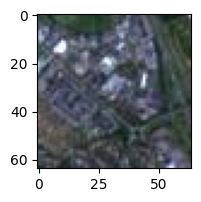

In [33]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data.shape
plt.figure(figsize=(4, 2))
plt.imshow(image_data)

<b>Strategy 1 — Memory-Based Loading</b><br>
Load every single image from disk into RAM at once, store them all as a big NumPy array.

In [35]:
%%time

non_agri_images = []
non_agri = os.scandir(dir_non_agri)

for file_name in non_agri:
    if os.path.isfile(file_name):
        image_name = str(file_name).split("'")[1]
        image_data = plt.imread(os.path.join(dir_non_agri,image_name))
        non_agri_images.append(image_data)

non_agri_images = np.array(non_agri_images)        

CPU times: total: 2.08 s
Wall time: 2.09 s


In [36]:
%%time
agri_images = []

for entry in os.scandir(dir_agri):
    if entry.is_file():
        image_data = plt.imread(entry.path)
        agri_images.append(image_data)

agri_images = np.array(agri_images)

CPU times: total: 1.56 s
Wall time: 1.6 s


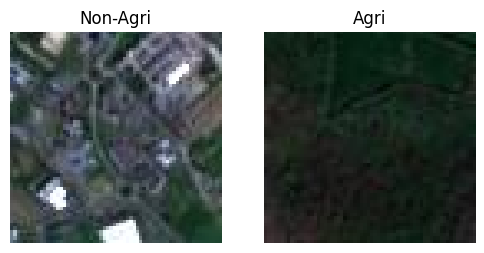

In [37]:
plt.figure(figsize=(6, 3))

# Left image (non-agri)
plt.subplot(1, 2, 1)
plt.imshow(non_agri_images[1])
plt.title("Non-Agri")
plt.axis('off')

# Right image (agri)
plt.subplot(1, 2, 2)
plt.imshow(agri_images[1])
plt.title("Agri")
plt.axis('off')

plt.show()

<b>Strategy 2 — Generator/Path-Based </b><br>
Store only the file paths (strings) in memory. Open each image only when you actually need it — one at a time or one batch at a time.

In [43]:
non_agri_images = os.listdir(dir_non_agri) #listdir gives names only
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [44]:
non_agri_images.sort()

In [45]:
non_agri_images_paths = [os.path.join(dir_non_agri,image) for image in non_agri_images]
non_agri_images_paths[:5]

['..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [46]:
len(non_agri_image_paths)

3000

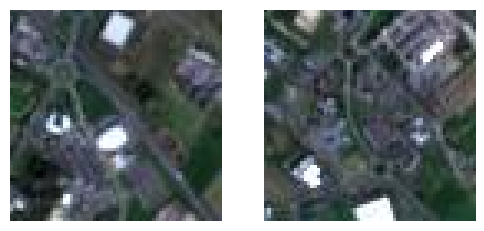

In [47]:
plt.figure(figsize=(6, 3))

for i in range(2):
    img = Image.open(non_agri_images_paths[i])

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [54]:
agri_images = os.listdir(dir_agri)
agri_images.sort()
agri_images_path = [os.path.join(dir_agri,image) for image in agri_images]
len(agri_images_path)

3000

<function matplotlib.pyplot.show(close=None, block=None)>

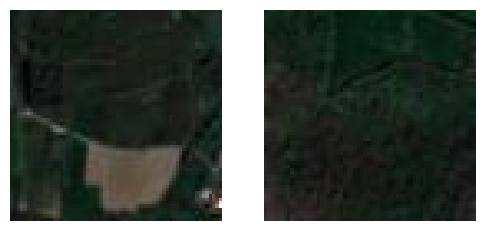

In [55]:
plt.figure(figsize=(6,3))

for i in range(2):
    img = Image.open(agri_images_path[i])
    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show